In [1]:
!pip install transformers torch pandas

  Using cached torch-2.9.1-cp313-cp313-win_amd64.whl.metadata (30 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-2.4.1-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.1.15-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd

df = pd.read_excel("comments.xlsx") 
print(df.head(10))

                                        comment_text  \
0                2025 Məzarın Nurla Dolsun Rüfət 🥀🥀🥀   
1  Allah rəhmət eləsin! Çox gözəl ,qəlbə toxunan ...   
2  Belə sənətkarlar həyatda olmadığı üçün artıq z...   
3  2024 iyun hələ də qulaq asıb zövq alıram. Alla...   
4  2025 ci il.. İfa etdiyiniz mahnılar hələ də di...   
5          Heyif bu senetkardan.Allah rehmet elesin.   
6   Hardasan köhne Baki, hardasan cavanligim....ehhh   
7  Allah səni rəhmət eləsin həyat dolu arzular do...   
8  Her axsam eve iwden eve gedende masinda en azi...   
9                           Allah sənə rəhmət eləsin   

                                          clean_text  like_count  reply_count  \
0        2025-ci il, məzarın nurla dolsun, Rüfət 🥀🥀🥀          41            2   
1  Allah rəhmət eləsin! Çox gözəl, qəlbə toxunan ...         151            2   
2  Belə sənətkarlar həyatda olmadığı üçün artıq z...          18            0   
3  2024-cü ilin iyun ayıdır, hələ də qulaq asıb z...       

In [5]:
from transformers import pipeline

sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")


Device set to use cpu


In [ ]:
from transformers import pipeline

# Multilingual sentiment modeli
sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=-1)  # CPU

# Thresholdlar
thresholds = [0.6, 0.8]

# Nəticələri saxlayacaq dictionary
results = {}

for th in thresholds:
    pos = 0
    neg = 0
    neu = 0
    
    for text in df['clean_text']:
        res = sentiment_analyzer(text[:512])[0]  # text uzunluğu çoxdursa 512 tokenlə məhdudlaşdırırıq
        score = float(res['score'])
        label = res['label']
        
        # Label ulduz sayına çevirmək (1-5)
        stars = int(label.split()[0])
        
        # Sentiment mapping + threshold
        if stars >= 4 and score >= th:
            pos += 1
        elif stars <= 2 and score >= th:
            neg += 1
        else:
            neu += 1
    
    results[th] = {'Positive': pos, 'Negative': neg, 'Neutral': neu}

# Nəticəni göstər
for th, res in results.items():
    print(f"\nThreshold = {th}")
    print(res)


Device set to use cpu



Threshold = 0.6
{'Positive': 30, 'Negative': 3, 'Neutral': 67}

Threshold = 0.8
{'Positive': 3, 'Negative': 1, 'Neutral': 96}


In [8]:
# Comment Length Filtering
length_filters = {
    "Less than 5 words": df[df['clean_text'].str.split().str.len() < 5],
    "More than 7 words": df[df['clean_text'].str.split().str.len() > 7]
}

for filter_name, filtered_df in length_filters.items():
    print(f"\n--- {filter_name} ---")
    print(f"Number of comments: {len(filtered_df)}")
    
    results = {}
    
    for th in thresholds:
        pos = neg = neu = 0
        
        for text in filtered_df['clean_text']:
            res = sentiment_analyzer(text[:512])[0]
            score = float(res['score'])
            label = res['label']
            stars = int(label.split()[0])
            
            if stars >= 4 and score >= th:
                pos += 1
            elif stars <= 2 and score >= th:
                neg += 1
            else:
                neu += 1
        
        results[th] = {
            'Positive': pos,
            'Negative': neg,
            'Neutral': neu
        }
    
    for th, res in results.items():
        print(f"Confidence threshold = {th}: {res}")



--- Less than 5 words ---
Number of comments: 19
Confidence threshold = 0.6: {'Positive': 5, 'Negative': 0, 'Neutral': 14}
Confidence threshold = 0.8: {'Positive': 0, 'Negative': 0, 'Neutral': 19}

--- More than 7 words ---
Number of comments: 40
Confidence threshold = 0.6: {'Positive': 13, 'Negative': 0, 'Neutral': 27}
Confidence threshold = 0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 38}


In [9]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.1.0-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)
Note: you may need to restart the kernel to use updated packages.


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


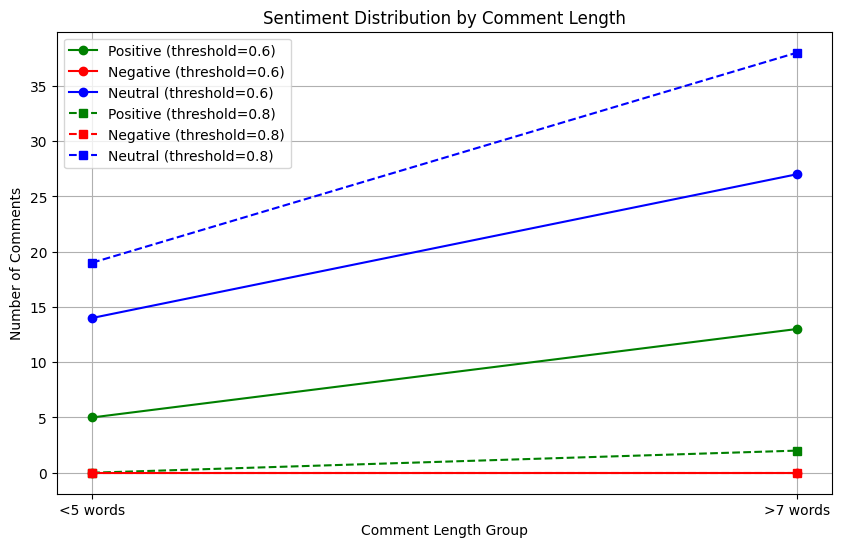

In [12]:
#Nəticələri dictionarydə saxlayırıq
import matplotlib.pyplot as plt

results_len = {
    '<5 words': {
        0.6: {'Positive': 5, 'Negative': 0, 'Neutral': 14},
        0.8: {'Positive': 0, 'Negative': 0, 'Neutral': 19}
    },
    '>7 words': {
        0.6: {'Positive': 13, 'Negative': 0, 'Neutral': 27},
        0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 38}
    }
}

length_groups = list(results_len.keys())
thresholds = [0.6, 0.8]


#Plot
plt.figure(figsize=(10,6))

colors = {'Positive':'green', 'Negative':'red', 'Neutral':'blue'}
markers = {0.6:'o', 0.8:'s'}

for th in thresholds:
    for sentiment in ['Positive','Negative','Neutral']:
        values = [results_len[g][th][sentiment] for g in length_groups]
        plt.plot(length_groups, values,
                 marker=markers[th],
                 linestyle='--' if th == 0.8 else '-',
                 color=colors[sentiment],
                 label=f'{sentiment} (threshold={th})')

plt.title('Sentiment Distribution by Comment Length')
plt.xlabel('Comment Length Group')
plt.ylabel('Number of Comments')
plt.legend()
plt.grid(True)
plt.show()


The plot clearly illustrates that short comments (<5 words) rapidly shift toward neutrality as the confidence threshold increases, while longer comments (>7 words) retain a higher proportion of positive sentiment. This confirms that semantic richness and contextual depth significantly improve sentiment confidence.

In [13]:
pip install textblob

  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached textblob-0.19.0-py3-none-any.whl (624 kB)
Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# Emoji sentiment mapping
emoji_sentiment = {
    '❤️':'Positive', '💓':'Positive','🥰':'Positive','💟':'Positive',
    '😢':'Negative','💔':'Negative','😔':'Negative','👹':'Negative','🤦':'Negative',
    '🙏':'Neutral','🥀':'Neutral','🌷':'Neutral','☪️':'Neutral'
}
import pandas as pd

# Uyğunsuzluqları topladığımız list
inconsistent_comments = []

for i, row in df.iterrows():
    text_sentiment = sentiment_analyzer(row['clean_text'][:512])[0]['label']
    stars = int(text_sentiment.split()[0])
    text_sent = 'Positive' if stars >= 4 else 'Negative' if stars <= 2 else 'Neutral'
    
    emojis = row['emojis']
    emoji_sent = None
    if isinstance(emojis, str) and emojis.strip():  # NaN yoxlanışı + boş string yoxlanışı
        e = emojis[0]  # yalnız ilk emoji
        emoji_sent = emoji_sentiment.get(e, 'Neutral')
    
    if emoji_sent and emoji_sent != text_sent:
        inconsistent_comments.append({
            'clean_text': row['clean_text'],
            'text_sentiment': text_sent,
            'emoji_sentiment': emoji_sent,
            'emojis': emojis
        })

# DataFrame-ə çeviririk
inconsistent_df = pd.DataFrame(inconsistent_comments)

print(f"Inconsistent comments found: {len(inconsistent_df)}\n")
print(inconsistent_df)


Inconsistent comments found: 33

                                           clean_text text_sentiment  \
0         2025-ci il, məzarın nurla dolsun, Rüfət 🥀🥀🥀       Positive   
1   Allah rəhmət eləsin! Çox gözəl, qəlbə toxunan ...       Positive   
2   Allah səni rəhmət eləsin. Arzuları, həyatı yar...       Positive   
3   Allah rəhmət eləsin sənə, sənətkar. Sən bir ba...       Positive   
4   Yaxşı insanlar niyə tez köçür bu dünyadan, bil...       Positive   
5   Biz də sizin üçün darıxmışıq. Allah sizi rəhmə...       Positive   
6   7 iyul – bu gün anım günüdür. Nur içində yatsın 🥀       Positive   
7                       Köhnə Bakı, gənclik illərim 😞       Positive   
8   Münhendə səni gözləyirəm. Gələndə bu mahnıya b...       Positive   
9   Ruhun şad olsun, sənətkar. Yerin çox görünür, ...       Positive   
10                              Necə gözəl mahnıdır 😍       Positive   
11  Allah rəhmət eləsin. Bu mahnını çoxları ifa ed...       Negative   
12  Ruhun şad olsun, gözəl adam

In [17]:
pip install sentence-transformers scikit-learn

  Using cached sentence_transformers-5.2.0-py3-none-any.whl.metadata (16 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached sentence_transformers-5.2.0-py3-none-any.whl (493 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl (36.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from collections import Counter
import re

# 1. Modeli yükləyirik
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 2. Textləri listə çeviririk
texts = df['clean_text'].tolist()
likes = df['like_count'].tolist()
replies = df['reply_count'].tolist()

# 3. Embeddings yaradılır
print("Generating embeddings...")
embeddings = model.encode(texts, convert_to_tensor=False)
print("Embeddings done.")

# 4. Cosine similarity matrisi
cos_sim = cosine_similarity(embeddings)
print("Cosine similarity matrix calculated.")

# 5. Threshold təyin edirik və qrupları tapırıq
threshold = 0.7
groups = []
visited = set()

for i in range(len(texts)):
    if i in visited:
        continue
    group = [i]
    visited.add(i)
    for j in range(i+1, len(texts)):
        if cos_sim[i][j] >= threshold:
            group.append(j)
            visited.add(j)
    groups.append(group)

print(f"\nTotal semantic groups found: {len(groups)}")

# 6. Outliers
outliers = [group[0] for group in groups if len(group) == 1]
print(f"\nNumber of semantic outliers: {len(outliers)}")
print("Outlier comments:")
for idx in outliers:
    print(f"- {texts[idx]}")

# 7. Most liked / replied comments
top_likes = df.nlargest(10, 'like_count')['clean_text'].tolist()
top_replies = df.nlargest(10, 'reply_count')['clean_text'].tolist()

def extract_common_words(text_list, top_n=10):
    all_words = []
    for t in text_list:
        words = re.findall(r'\b\w+\b', t.lower())
        all_words.extend(words)
    counter = Counter(all_words)
    return counter.most_common(top_n)

print("\nTop words in most liked comments:")
for word, count in extract_common_words(top_likes):
    print(f"{word}: {count}")

print("\nTop words in most replied comments:")
for word, count in extract_common_words(top_replies):
    print(f"{word}: {count}")


Generating embeddings...
Embeddings done.
Cosine similarity matrix calculated.

Total semantic groups found: 38

Number of semantic outliers: 20
Outlier comments:
- Hər axşam işdən evə gedərkən maşında ən azı 4–5 dəfə bu musiqini dinləyirəm. Burada sənət, harmoniya və möhtəşəm ifa var.
- Bu gün Qubada istirahət mərkəzində mahnılarını eşitdim. Unudulmursan.
- Yaxşı insanlar niyə tez köçür bu dünyadan, bilən var? 😢🤲😔
- Yaxşı ki bu musiqilər var. Heyif ki bu cür mahnıların dinləyicisi azdır. Bizim dəyərli musiqilərimizdi.
- 15–16 yaşlarım idi. Radioda bu mahnını dinləyə-dinləyə xəyallara dalırdım. 1991-dən 2005-2010-cu illərə kimi Azərbaycanda hələ də zövq deyilən bir şey var idi.
- Hər yağış yağanda bura gəlirəm.
- 90-ların sonu, 2000-lərin əvvəli estradamızın parlaq dövrü idi - zövqlü istedadlı müğənnileə və əlbəttə ki, Nadir Əzimov, Xanım İsmayılqızı , Novruz Aslan, Nailə Mirməmmədli kimi istedadlı şair və bəstəkarlarımız.
- Bir gün mən olmasam, bu mahnını dinləyəcəksən.
- Aranjeman ço

In [21]:
# 5 semantic category mapping
def categorize_comment(text):
    text_lower = text.lower()
    # 1. Rational positive feedback
    if any(word in text_lower for word in ['gözəl', 'möhtəşəm', 'sənət', 'ifası', 'təşəkkür']):
        return 'Rational positive feedback'
    # 2. Emotional reaction
    elif any(word in text_lower for word in ['darix', 'üzül', 'hüzün', 'şad olsun', 'ruh']):
        return 'Emotional reaction'
    # 3. Criticism and dissatisfaction
    elif any(word in text_lower for word in ['heyif', 'pis', 'səviyyəsiz', 'düşük']):
        return 'Criticism and dissatisfaction'
    # 4. Direct address to author
    elif any(word in text_lower for word in ['siz', 'sən', 'rüfət', 'müəllim']):
        return 'Direct address to the author'
    # 5. Troll / non-constructive
    else:
        return 'Troll / non-constructive'

# Yeni column əlavə edirik
df['semantic_category'] = df['clean_text'].apply(categorize_comment)

# Sentiment analizi üçün funksiyanı istifadə edirik
def get_sentiment(text):
    res = sentiment_analyzer(text[:512])[0]
    stars = int(res['label'].split()[0])
    return 'Positive' if stars >= 4 else 'Negative' if stars <= 2 else 'Neutral'

df['sentiment_label'] = df['clean_text'].apply(get_sentiment)

# Nəticəni cədvəl şəklində toplamaq
categories = df['semantic_category'].unique()
summary = []

for cat in categories:
    subset = df[df['semantic_category'] == cat]
    pos = sum(subset['sentiment_label'] == 'Positive')
    neg = sum(subset['sentiment_label'] == 'Negative')
    neu = sum(subset['sentiment_label'] == 'Neutral')
    summary.append([cat, pos, neg, neu])

import pandas as pd
summary_df = pd.DataFrame(summary, columns=['Semantic Category', 'Positive', 'Negative', 'Neutral'])
print(summary_df)


               Semantic Category  Positive  Negative  Neutral
0   Direct address to the author        22         3        0
1     Rational positive feedback        26         5        0
2       Troll / non-constructive        18        16        1
3  Criticism and dissatisfaction         4         1        2
4             Emotional reaction         0         2        0


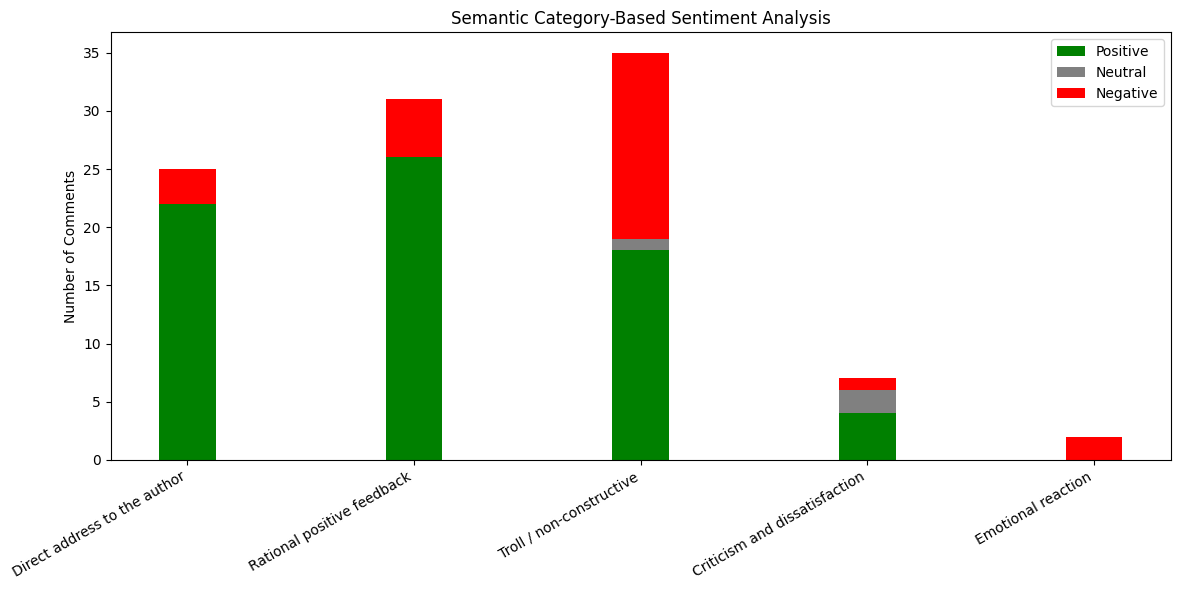

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Yeni data
data = {
    "Category": [
        "Direct address to the author",
        "Rational positive feedback",
        "Troll / non-constructive",
        "Criticism and dissatisfaction",
        "Emotional reaction"
    ],
    "Positive": [22, 26, 18, 4, 0],
    "Negative": [3, 5, 16, 1, 2],
    "Neutral":  [0, 0, 1, 2, 0]
}

df_plot = pd.DataFrame(data)

# Bar plot üçün hazırlıq
categories = df_plot['Category']
x = range(len(categories))

plt.figure(figsize=(12,6))

plt.bar(x, df_plot['Positive'], width=0.25, label='Positive', color='green', align='center')
plt.bar(x, df_plot['Neutral'], width=0.25, label='Neutral', color='gray', 
        bottom=df_plot['Positive'], align='center')
plt.bar(x, df_plot['Negative'], width=0.25, label='Negative', color='red', 
        bottom=df_plot['Positive'] + df_plot['Neutral'], align='center')

plt.xticks(x, categories, rotation=30, ha='right')
plt.ylabel("Number of Comments")
plt.title("Semantic Category-Based Sentiment Analysis")
plt.legend()
plt.tight_layout()
plt.show()
